<a href="https://colab.research.google.com/github/LucianoBV/Procesamiento-del-habla/blob/main/TP1_Pr%C3%A1ctica_Profesionalizante_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

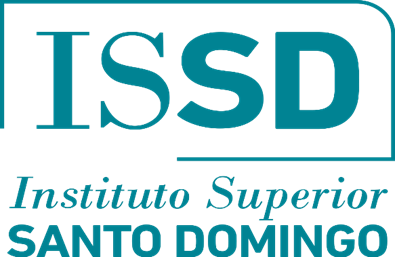

##**Docente: Data science & AI professor, Julio Paredes Rojas**

##**Alumno: Vargas Luciano Benjamín, DNI 26.462.057**

#📊 Proyecto de Ciencia de Datos: Predicción de Abandono de Clientes usando KNN

##🧩 1 - Contexto del Proyecto
Las empresas de telecomunicaciones enfrentan pérdidas importantes debido a la fuga de clientes. Anticipar qué clientes podrían abandonar permite diseñar estrategias de retención más eficaces y personalizadas.

##🎯 2 - Objetivo
Desarrollar un modelo de predicción utilizando el algoritmo K-Nearest Neighbors (KNN) para identificar a los clientes con mayor probabilidad de abandonar la empresa, a partir de sus características de uso y perfil.

##🧠 3 - Justificación del uso de KNN

Útil en contextos donde la relación entre variables es no lineal.

La intuición de "clientes similares tienden a comportarse igual" se alinea bien con la filosofía de KNN.

##🗂️ 4 - Descripción del Dataset
Fuente: Datos simulados de una compañía de telecomunicaciones.

#🛠️ 5 - Proceso del Proyecto

##*Preprocesamiento de datos*

Limpieza de valores nulos.

División en conjunto de entrenamiento y prueba

##*Entrenamiento del modelo KNN*

Búsqueda del mejor valor de k (validación cruzada).

##*Evaluación del modelo*

Métricas: Accuracy, Precision, Recall, F1-score.

Matriz de confusión.

##*Interpretación y aplicación*

Identificar perfiles de clientes con mayor probabilidad de abandonar.

Sugerencias de acciones para retención (descuentos, contacto proactivo, mejoras de servicio).

#📈 6 - Resultados Esperados
Precisión razonable en la predicción de cancelación.

Identificación de patrones relevantes asociados con mayor abandono.

In [257]:
#Importamos librerías necesarias para nuestro proyecto.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [258]:
#Leemos el data set que esta en formato CSV.
df = pd.read_csv("customer_churn_dataset-testing-master.csv")

In [259]:
# Mostramos información general del DataFrame y las 5 primeras filas
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [260]:
# Comprobamos si hay valores nulos en cada columna del DataFrame
df.isnull().sum()


,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [261]:
# Renombramos las columnas para un mejor entendimiento
df.rename(columns={
    'CustomerID': 'Identificación del cliente',
    'Age': "Edad",
    'Gender': 'Género',
    'Tenure': 'Titularidad',
    'Usage Frequency': 'Frecuencia de uso',
    'Support Calls': 'Llamadas de soporte',
    'Payment Delay': 'Retraso en el pago',
    'Subscription Type': 'Tipo de suscripción',
    'Contract Length': 'Duración del contrato',
    'Total Spend': 'Gasto total',
    'Last Interaction': 'Última interacción',
    'Churn': 'Cancelación'

}, inplace=True)

In [262]:
# Eliminamos las columnas que no nos interesan para éste análisis.
df = df.drop(columns=["Identificación del cliente","Titularidad","Género","Tipo de suscripción", "Duración del contrato"])

In [263]:
# Se imprime el dataframe despues de eliminar las columna para verificar que se realizo correctamente.
df.head()


,Edad,Frecuencia de uso,Llamadas de soporte,Retraso en el pago,Gasto total,Última interacción,Cancelación
0,22,14,4,27,598,9,1
1,41,28,7,13,584,20,0
2,47,10,2,29,757,21,0
3,35,12,5,17,232,18,0
4,53,24,9,2,533,18,0


In [264]:
# Se verifica la cantidad de filas actual del DataFrame
cantidad_filas_actual = len(df)

# Se calcula la cantidad de filas a eliminar
filas_a_eliminar = 50000

# Se verifica si la cantidad de filas a eliminar es menor a la cantidad de filas actuales
if filas_a_eliminar < cantidad_filas_actual:
    # Se eliminan las últimas filas_a_eliminar filas
    df = df[:-filas_a_eliminar]
    print(f"Se eliminaron las últimas {filas_a_eliminar} filas del DataFrame.")
else:
    # Si se intenta eliminar más filas de las que existen se imprime un mensaje.
    print("No se pueden eliminar 50000 filas, el DataFrame tiene menos filas.")


Se eliminaron las últimas 50000 filas del DataFrame.


In [265]:
# Descripción general del DataFrame
print(df.info())  # Muestra el tipo de dato de cada columna y la cantidad de valores no nulos.
print(df.describe())  # Estadísticas descriptivas de las columnas numéricas (media, desviación estándar, etc.).

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14374 entries, 0 to 14373
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Edad                 14374 non-null  int64
 1   Frecuencia de uso    14374 non-null  int64
 2   Llamadas de soporte  14374 non-null  int64
 3   Retraso en el pago   14374 non-null  int64
 4   Gasto total          14374 non-null  int64
 5   Última interacción   14374 non-null  int64
 6   Cancelación          14374 non-null  int64
dtypes: int64(7)
memory usage: 786.2 KB
None
               Edad  Frecuencia de uso  Llamadas de soporte  \
count  14374.000000       14374.000000         14374.000000   
mean      41.557882          15.560039             4.959928   
std       13.784451           8.633157             3.159558   
min       18.000000           1.000000             0.000000   
25%       30.000000           8.000000             2.000000   
50%       41.000000          15.00000

##🔎 Análisis rápido del dataset:

Filas: 14.374 clientes.

Columnas: 7 (todas numéricas y sin valores nulos).

Variables:

Edad

Frecuencia de uso

Llamadas de soporte

Retraso en el pago

Gasto total

Última interacción

Cancelación (0 = No canceló, 1 = Canceló ➔ nuestra variable objetivo).

# Proceso de EDA

In [266]:
# Verificar información general del dataframe
eda_info = df.describe().T
eda_info

,count,mean,std,min,25%,50%,75%,max
Edad,14374.0,41.557882,13.784451,18.0,30.0,41.0,53.0,65.0
Frecuencia de uso,14374.0,15.560039,8.633157,1.0,8.0,15.0,23.0,30.0
Llamadas de soporte,14374.0,4.959928,3.159558,0.0,2.0,5.0,8.0,10.0
Retraso en el pago,14374.0,15.061013,8.962842,0.0,7.0,15.0,23.0,30.0
Gasto total,14374.0,548.581745,261.074249,100.0,320.0,548.0,775.0,1000.0
Última interacción,14374.0,15.509670,8.618559,1.0,8.0,16.0,23.0,30.0
Cancelación,14374.0,0.259357,0.438297,0.0,0.0,0.0,1.0,1.0


##Este gráfico muestra la distribución univariada de varias variables numéricas del dataset.



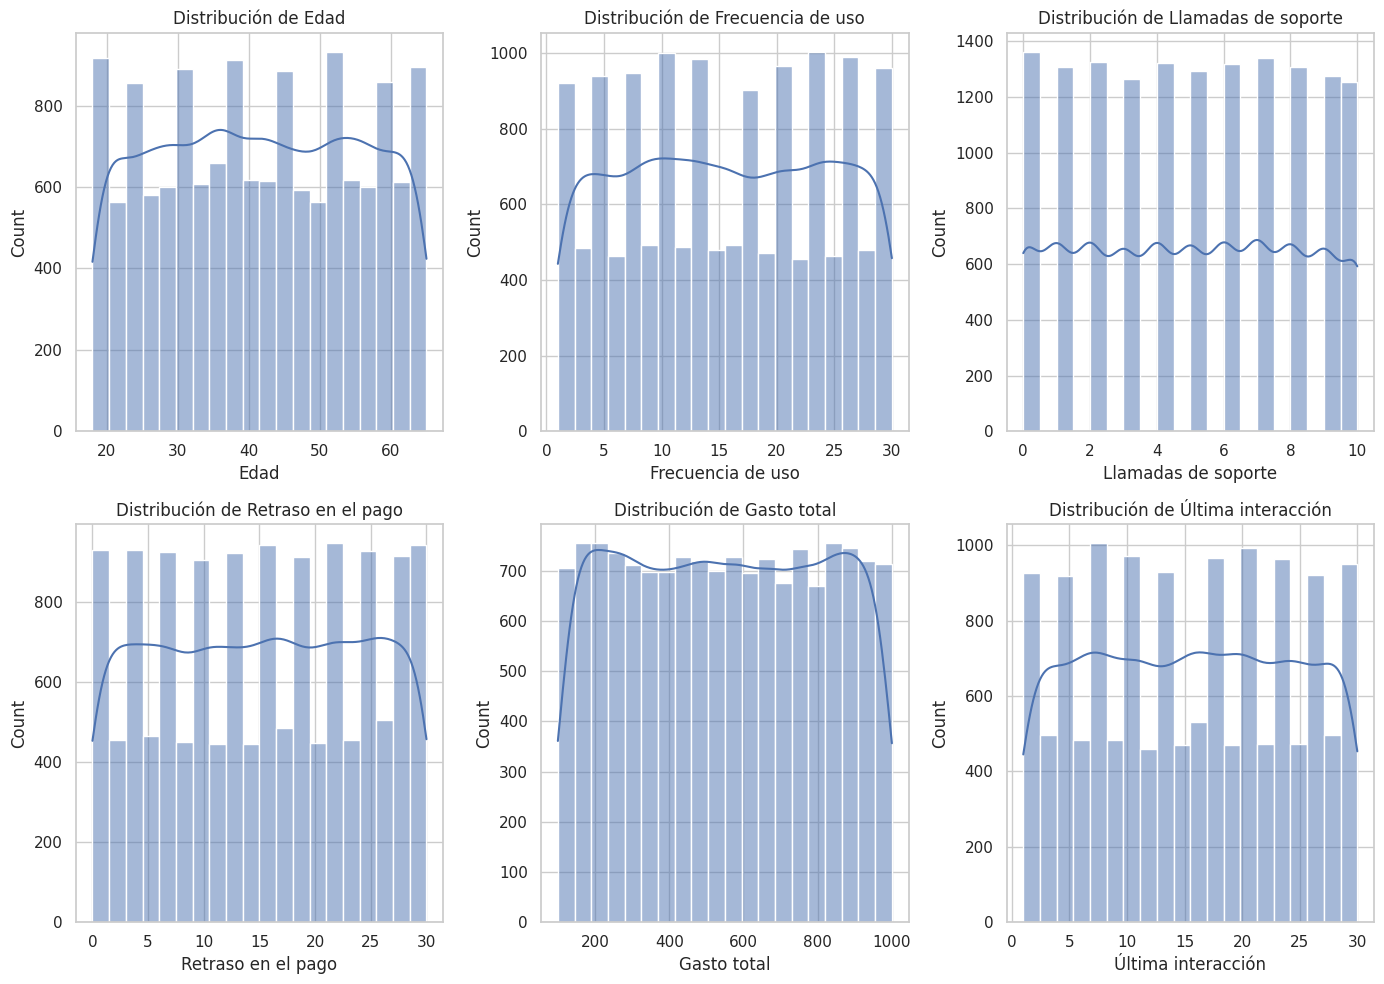

In [267]:
# Graficar distribución de las variables numéricas
plt.figure(figsize=(14, 10))
for i, column in enumerate(df.columns[:-1]):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[column], kde=True, bins=20)
    plt.title(f'Distribución de {column}')
plt.tight_layout()
plt.show()

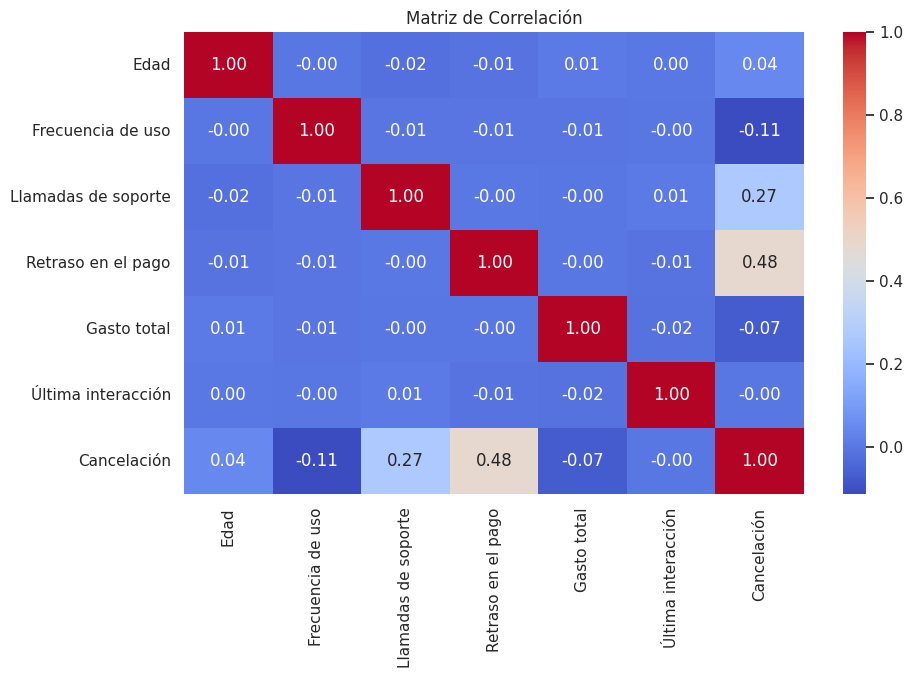

In [268]:
# Gráfico de correlación en gráfico de calor.
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

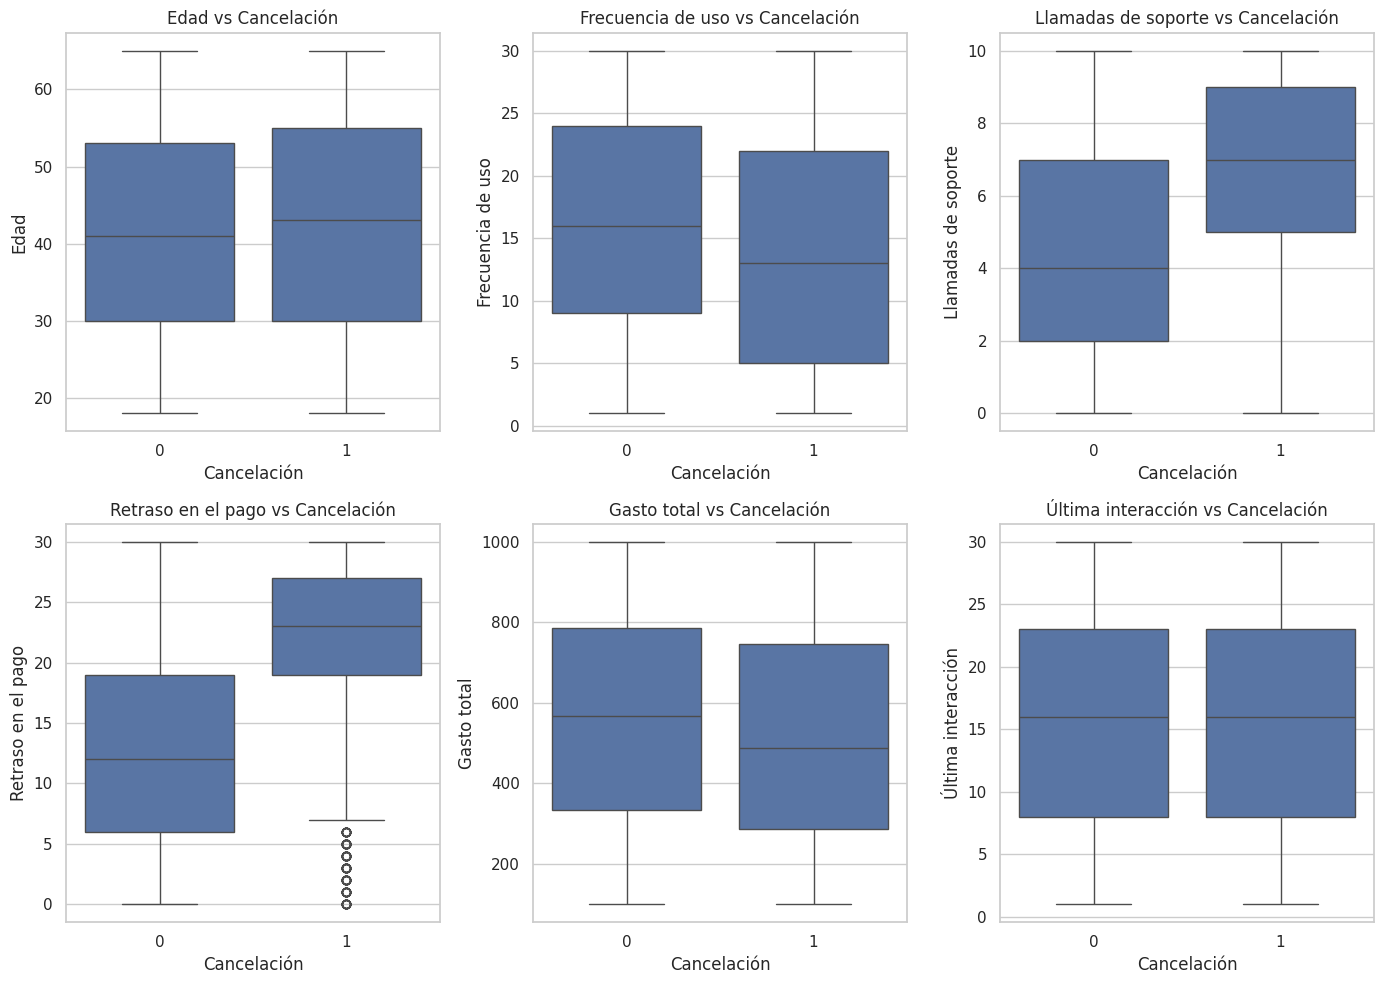

In [269]:
# Comparar variables con respecto a la variable objetivo (Cancelación)
plt.figure(figsize=(14, 10))
for i, column in enumerate(df.columns[:-1]):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='Cancelación', y=column, data=df)
    plt.title(f'{column} vs Cancelación')
plt.tight_layout()
plt.show()

##🔍 Observaciones clave:
La matriz de correlación muestra algunas correlaciones moderadas, especialmente entre:

Las variables Retraso en el pago y Llamadas de soporte son los factores más relevantes correlacionados con la cancelación.

Frecuencia de uso tiene correlación negativa débil. Una menor frecuencia de uso se asocia ligeramente con una mayor probabilidad de cancelación, lo que es lógico si el cliente no encuentra valor en el servicio.



Los boxplots por clase (Cancelación) revelan que los clientes que cancelan tienden a:

Tener menos interacción reciente.

Mostrar mayor retraso en los pagos.

Tener mayor cantidad de llamadas a soporte.

# Armado de modelo

In [270]:


# Separar variables predictoras (X) y objetivo (y)
X = df.drop("Cancelación", axis=1)
y = df["Cancelación"]

# Escalar las variables (muy importante para KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Mostrar tamaños de los conjuntos resultantes
{
    "Tamaño del conjunto de entrenamiento": X_train.shape,
    "Tamaño del conjunto de prueba": X_test.shape
}


{'Tamaño del conjunto de entrenamiento': (11499, 6),
 'Tamaño del conjunto de prueba': (2875, 6)}

##Entrenamos el modelo KNN y buscamos el mejor valor de k usando validación cruzada 🔍📊 ​

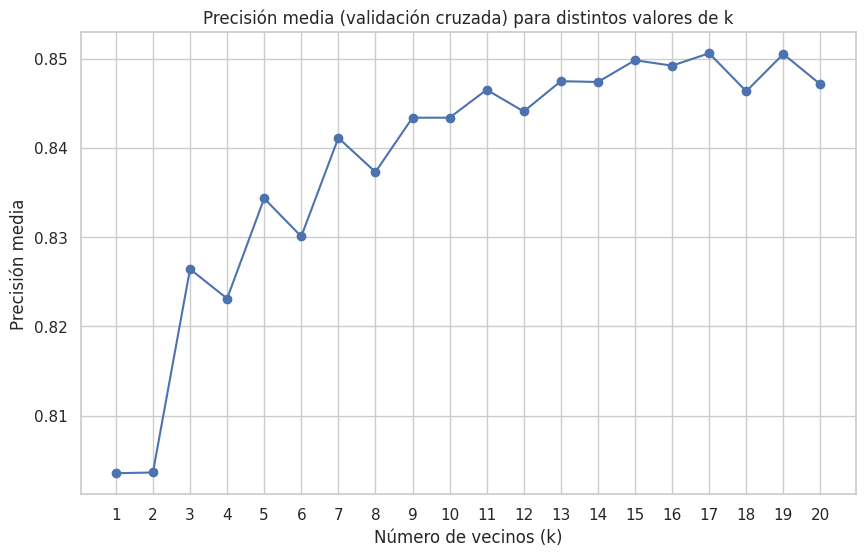

(17, np.float64(0.8505960247366531))

In [271]:


# Probar distintos valores de k
k_values = range(1, 21)
cv_scores = []

# Validación cruzada para cada k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Encontrar el mejor k
best_k = k_values[np.argmax(cv_scores)]
best_score = max(cv_scores)

# Graficar resultados
plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, marker='o')
plt.title('Precisión media (validación cruzada) para distintos valores de k')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Precisión media')
plt.xticks(k_values)
plt.grid(True)
plt.show()

best_k, best_score


##El mejor valor de k fue 17, con una precisión media (en validación cruzada) de aproximadamente 85.06%.

Esto indica que el modelo KNN con 17 vecinos logra una buena capacidad predictiva sobre los datos de entrenamiento.

In [272]:
# Entrenar modelo final
knn_final = KNeighborsClassifier(n_neighbors=17)
knn_final.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=17)

In [273]:
# Predecir sobre el conjunto de prueba
y_pred = knn_final.predict(X_test)

In [274]:
# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

In [275]:
{
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
}

{'Accuracy': 0.8500869565217392,
 'Precision': 0.7426810477657936,
 'Recall': 0.646112600536193,
 'F1-Score': 0.6910394265232975}

In [276]:
import plotly.graph_objects as go

# Crear matriz de confusión interactiva con Plotly
labels = ["No Canceló", "Canceló"]
z = confusion_matrix(y_test, y_pred)

fig = go.Figure(data=go.Heatmap(
    z=z,
    x=labels,
    y=labels,
    colorscale='Blues',
    hoverongaps=False,
    showscale=True,
    text=z,
    texttemplate="%{text}",
))

fig.update_layout(
    title="📊 Matriz de Confusión Interactiva - KNN (k=17)",
    xaxis_title="Predicción",
    yaxis_title="Real",
    autosize=True
)

fig.show()


📌 ¿Qué nos dice la matriz de confusión?  

Accuracy ≈ 85% → El 85% de todas las predicciones fueron correctas.

Precision ≈ 74% → De todos los que el modelo predijo como "cancelarán", el 74% realmente lo hicieron.

Recall ≈ 65% → De todos los clientes que realmente cancelaron, el modelo detectó el 65%.

F1-score ≈ 69% → Buen equilibrio entre precisión y recall.

##📊 Interpretación:
El modelo tiene una buena exactitud general (85%).

La precisión indica que, de todos los clientes que predijimos que cancelarían, un 74% realmente lo hizo.

El recall muestra que capturamos el 64% de todos los clientes que realmente cancelaron.


📄 Informe Final del Proyecto: Predicción de Abandono de Clientes usando KNN




📈 Principales hallazgos

Clientes que interactúan menos recientemente tienen mayor probabilidad de cancelar.

Mayor retraso en pagos y más llamadas de soporte también se asocian a un riesgo de abandono mayor.

Edad y frecuencia de uso presentan patrones más difusos pero igualmente relevantes.

🛡️ Recomendaciones de acción

Clientes con alta inactividad reciente:

Enviar comunicaciones personalizadas (descuentos, ofertas, contacto proactivo).

Clientes con múltiples llamadas de soporte:

Ofrecer soluciones rápidas y servicios premium de atención.

Clientes con frecuentes retrasos en pagos:

Ofrecer planes de financiamiento o recordatorios anticipados.

🎯 Conclusión

El modelo KNN desarrollado proporciona una herramienta para anticipar cancelaciones de clientes con alta precisión, permitiendo a la empresa tomar medidas preventivas y mejorar su retención de clientes.